# 01. toy classification -- 고정 형태 타깃과 stacked 배치

`00_engine.ipynb`가 다룬 공통 엔진 위에서, 가장 단순한 target 규약(고정 형태 정수 라벨)이 실제로
어떻게 흐르는지 확인한다. 로컬 데이터셋과 체크포인트 없이 CPU에서 완주한다.

In [1]:
import os
import sys


def find_repo_root(start):
    """Walk up from the notebook's own directory to the repository root (identified by the
    presence of `src/`), so `import src...` resolves regardless of where this notebook is run
    from (nbconvert executes with cwd set to the notebook's own directory)."""
    path = os.path.abspath(start)
    while not os.path.isdir(os.path.join(path, "src")):
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError("could not locate repository root (no 'src/' found above cwd)")
        path = parent
    return path


REPO_ROOT = find_repo_root(os.getcwd())
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)

# Mirrors src/__main__.py: arm the offline guard before any module that might touch the
# network at import time, then import src.tasks so every @DATASETS/@MODELS/@ADAPTERS/...
# decorator across the 4 tasks (+ toy) actually runs and populates the registries. Until this
# import happens, every Registry in src.core.registry is empty.
from src.core.offline import enable_offline_guard

enable_offline_guard()
import src.tasks  # noqa: F401,E402

print("cwd:", os.getcwd())

import torch

cwd: /mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate


## 데이터 -- `ToyClsDataset`

`src/tasks/toy/dataset.py`의 `ToyClsDataset`은 이미지를 `torch.randn`으로, 라벨을
`[0, num_classes)` 정수로 즉석에서 합성한다. 파일 시스템에 아무 것도 두지 않는다.

In [2]:
from src.core.registry import DATASETS

train_ds = DATASETS.build("toy_cls", root=".", split="train", transform=None,
                           image_size=(32, 32), num_classes=4)
image, label = train_ds[0]
print("image:", image.shape, image.dtype)
print("label:", label, label.dtype, label.shape)

image: torch.Size([3, 32, 32]) torch.float32
label: tensor(0) torch.int64 torch.Size([])


`label`은 0-dim 텐서(스칼라)다 -- 이미지마다 크기가 달라질 수 있는 Detection/Anomaly의 target과
달리, 배치 내 모든 샘플의 target이 정확히 같은 shape를 갖는 가장 단순한 경우다.

## `collate_fn` -- 기본 `default_collate`로 충분하다

`TaskAdapter.collate_fn()`의 기본 구현은 `None`을 반환하며, `DataLoader`는 `None`이면 PyTorch
기본 `default_collate`를 쓴다. 모든 샘플의 image/label이 같은 shape이므로 이것으로 충분히 스택된
배치가 만들어진다 -- `toy_cls` 어댑터는 `collate_fn`을 오버라이드하지 않는다.

In [3]:
from src.core.registry import ADAPTERS

ToyClsAdapter = ADAPTERS.get("toy_cls")
adapter = ToyClsAdapter(loss_fn=None, metrics={})
print("adapter.collate_fn():", adapter.collate_fn())

from torch.utils.data import DataLoader

loader = DataLoader(train_ds, batch_size=8, shuffle=False)
batch_images, batch_labels = next(iter(loader))
print("batch images:", batch_images.shape, batch_images.dtype)
print("batch labels:", batch_labels.shape, batch_labels.dtype)

adapter.collate_fn(): None
batch images: torch.Size([8, 3, 32, 32]) torch.float32
batch labels: torch.Size([8]) torch.int64


## 어댑터 계약 -- `ToyClsAdapter`

`train_step`은 이미지/라벨을 device로 옮기고 모델에 통과시켜 loss를 만든다. `predict_step`은
`argmax`로 라벨을 고른 뒤 배치 크기만큼의 dict 리스트를 반환한다 (`TaskAdapter.predict_step`
계약: "Return one serializable prediction per sample in the batch").

In [4]:
import inspect

print(inspect.getsource(ToyClsAdapter))

@ADAPTERS.register("toy_cls")
class ToyClsAdapter(TaskAdapter):
    def train_step(self, model, batch, device):
        images, targets = batch
        images, targets = images.to(device), targets.to(device)
        return run_model_step(model, images, targets, self.loss_fn)

    def eval_step(self, model, batch, device):
        images, targets = batch
        images, targets = images.to(device), targets.to(device)
        outputs = model(images)
        loss = self.loss_fn(outputs, targets)
        preds = torch.argmax(outputs, dim=1)
        return {"loss": loss, "outputs": {"preds": preds.cpu(), "targets": targets.cpu()}}

    def update_metrics(self, outputs):
        preds, targets = outputs["outputs"]["preds"], outputs["outputs"]["targets"]
        for metric in self.metrics.values():
            metric.update(preds, targets)

    def compute_metrics(self):
        return {name: float(metric.compute()) for name, metric in self.metrics.items()}

    def reset_metrics(self):
     

## 학습 -- 5 epoch, CPU

`00_engine.ipynb`와 동일한 파이프라인(`build_transforms` -> `build_components` -> `build_dataset`
-> `build_dataloader` -> `build_optimizer`/`build_scheduler` -> `Trainer.fit`)을 그대로 사용한다.

In [5]:
import os

from src.cli.commands import bind_class_names, build_components, build_dataset, build_transforms
from src.core.builders import build_dataloader, build_optimizer, build_scheduler
from src.core.config import resolve_config, validate_config
from src.core.context import RunContext
from src.core.engine import Trainer
from src.core.logger import MetricsCsvWriter, setup_logger

config = validate_config(resolve_config("configs/toy/toy_cls.yaml"))
run_dir = os.path.join("outputs", "notebooks", "01_toy_cls")
os.makedirs(run_dir, exist_ok=True)

ctx = RunContext(config, run_dir)
ctx.setup_seed()

transform_train, transform_eval = build_transforms(config)
model, adapter = build_components(config)
adapter.to(ctx.device)
train_ds = build_dataset(config, "train", transform_train)
valid_ds = build_dataset(config, "valid", transform_eval)
bind_class_names(adapter, train_ds)

train_loader = build_dataloader(train_ds, config["data"], "train", adapter, ctx.seed,
                                 config["runtime"]["device"])
valid_loader = build_dataloader(valid_ds, config["data"], "valid", adapter, ctx.seed,
                                 config["runtime"]["device"])
optimizer = build_optimizer(config["optim"], model)
scheduler = build_scheduler(config["optim"], optimizer)

logger = setup_logger(run_dir, "WARNING")
metrics_writer = MetricsCsvWriter(run_dir, [m["name"] for m in config["metrics"]])
trainer = Trainer(logger=logger, metrics_writer=metrics_writer,
                   checkpoint_dir=os.path.join(run_dir, "checkpoints"))

best = trainer.fit(model, adapter, train_loader, valid_loader, optimizer, scheduler, ctx)
print("best valid accuracy:", best)

best valid accuracy: 0.21875


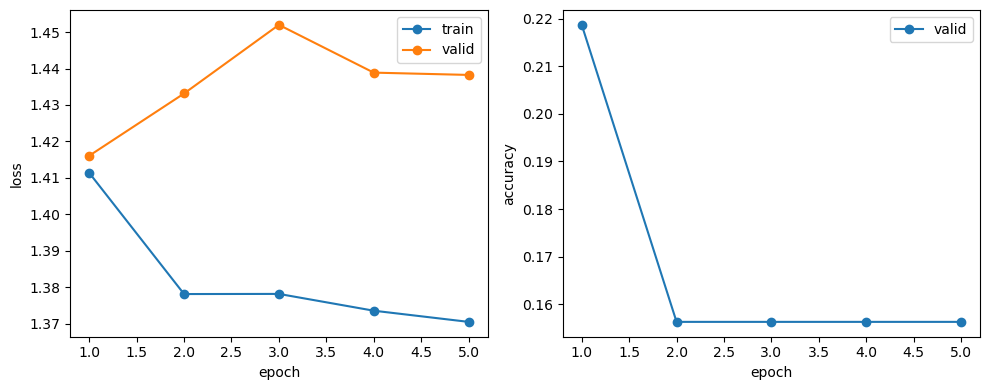

,epoch,split,loss,accuracy,lr,elapsed_sec
0,1,train,1.411377,NaN,0.001000,0.110572
1,1,valid,1.416086,0.21875,0.000000,0.010826
2,2,train,1.378151,NaN,0.000905,0.035876
3,2,valid,1.433152,0.15625,0.000000,0.008894
4,3,train,1.378189,NaN,0.000658,0.034254
5,3,valid,1.451978,0.15625,0.000000,0.009123
6,4,train,1.373586,NaN,0.000352,0.040550
7,4,valid,1.438875,0.15625,0.000000,0.009202
8,5,train,1.370521,NaN,0.000105,0.032978
9,5,valid,1.438246,0.15625,0.000000,0.009755


In [6]:
from notebooks.common import plot_training_curves

plot_training_curves(os.path.join(run_dir, "metrics_epoch.csv"), ["accuracy"])

## `predict_step` 출력 확인

계약대로 배치당 샘플 수만큼의 dict 리스트가 나오는지, 그리고 그 안에 스칼라 라벨(고정 형태 타깃)만
들어 있는지 확인한다.

In [7]:
model.eval()
sample_batch = next(iter(valid_loader))
with torch.no_grad():
    predictions = adapter.predict_step(model, sample_batch, ctx.device)

print("batch size:", sample_batch[0].shape[0], " predictions:", len(predictions))
predictions[:3]

batch size: 8  predictions: 8


[{'label': 1}, {'label': 1}, {'label': 1}]

## 요약

- `ToyClsDataset`은 이미지 `(3, H, W)` float와 라벨 스칼라 `long`을 반환한다 -- 배치 내 모든 target
  shape가 동일하다.
- 이 동일성 덕분에 `collate_fn`을 오버라이드할 필요가 없다 (`adapter.collate_fn()`이 `None`을
  반환하고 PyTorch 기본 `default_collate`가 그대로 동작한다).
- `predict_step`은 배치 크기만큼의 dict 리스트를 반환한다는 `TaskAdapter` 계약을 그대로 지킨다.

다음(`02_toy_seg.ipynb`)은 target이 스칼라가 아니라 픽셀 단위 `(H, W)` 텐서가 될 때 무엇이
달라지는지를 본다.